<a href="https://colab.research.google.com/github/sap156/infinityskillshub/blob/main/Named_Entity_Recognition_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative AI for Data Professionals
# Data Parsing and Extraction — Module 3 Part 3
# Named Entity Recognition (NER)


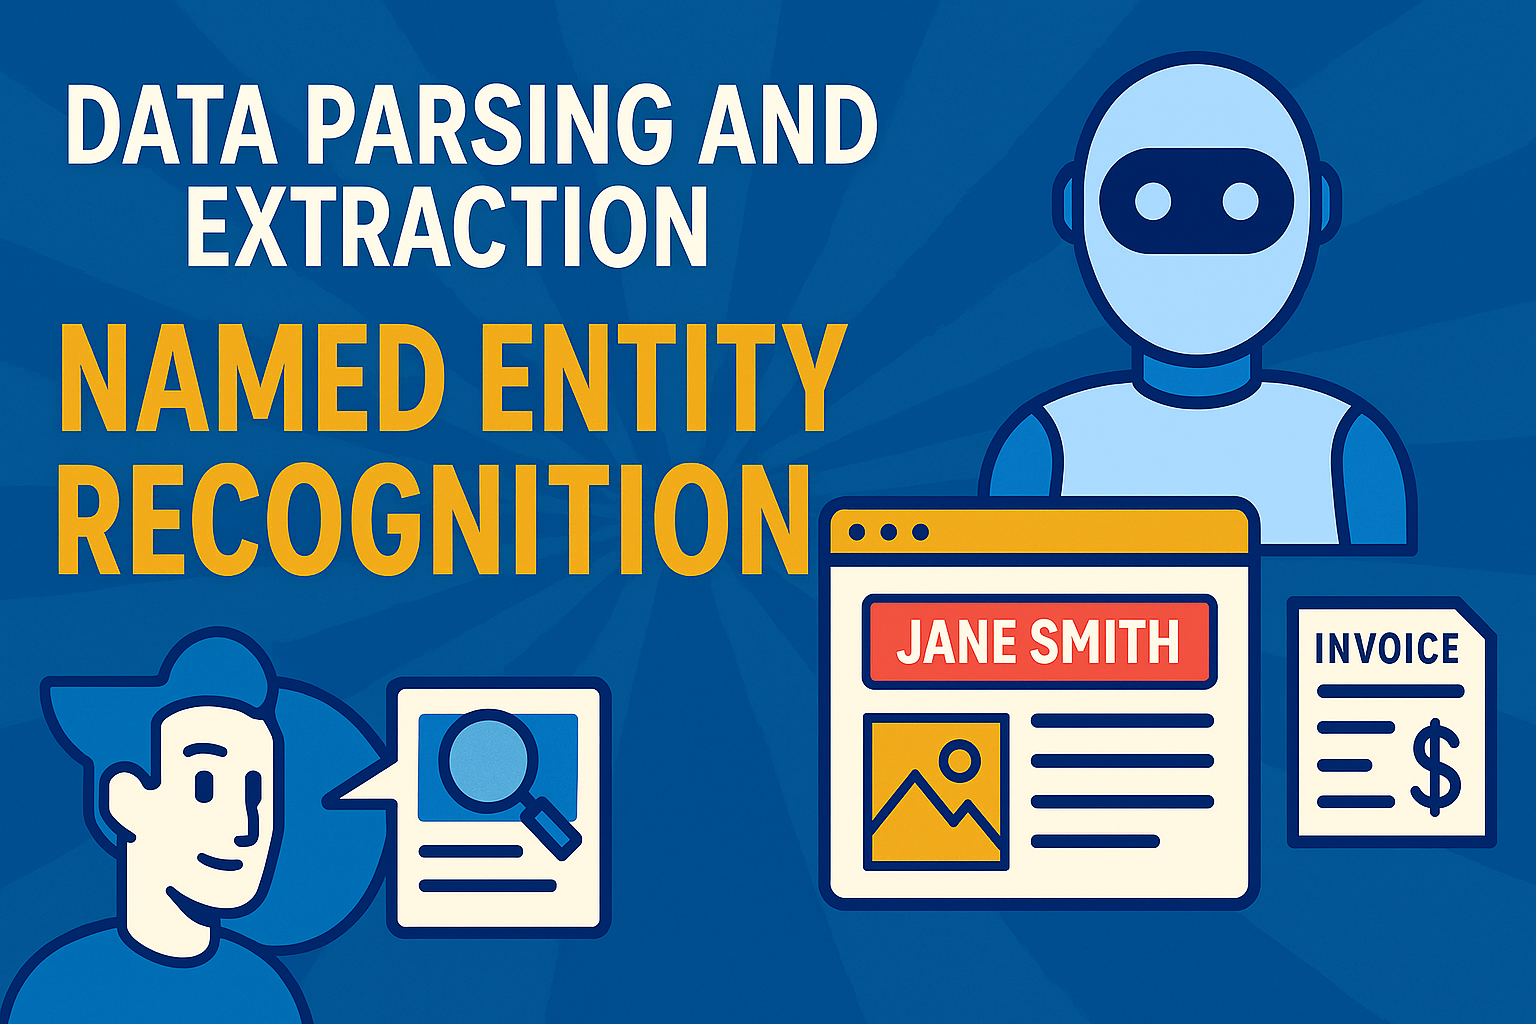


# 🔍 Named Entity Recognition with Generative AI

**Entity Recognition, also known as Named Entity Recognition (NER), is a natural
language processing (NLP) technique used to identify and classify key pieces of
information within a text. These entities can include names of people, organizations,
locations, dates, products, and more.**

Traditional NLP models have long been used for entity recognition, helping extract
structured information from unstructured text, making it easier to analyze large
datasets. However, **Generative AI** takes this concept even further by allowing
entity extraction with greater flexibility, adaptability, and minimal setup.

**Why Use Generative AI for Entity Recognition?**

* **No Predefined Rules Needed:** Traditional NER models require pre-training with
  extensive labeled datasets, whereas generative AI can recognize entities dynamically.
* **Context Awareness:** Generative AI can **understand text contextually**, ensuring
  better recognition of entities, even if they appear in different formats.
* **Easy Implementation:** Requires just a few lines of code with large language
  models (LLMs) like GPT instead of developing and fine-tuning NLP pipelines.
* **Handles Various Text Formats:** Whether it's **news articles, social media posts,
  contracts, or reviews**, generative AI can extract relevant entities with high accuracy.

Let's explore how **GPT-4o** can be used to perform Named Entity Recognition with
just a few API calls.

**Learning Objectives:**
- ✅ Extract named entities from simple text
- ✅ Process complex news articles for entity recognition
- ✅ Analyze social media posts for hashtags, mentions, and locations
- ✅ Understand the advantages of AI-powered NER over traditional methods
- ✅ Build scalable entity extraction workflows

In [2]:
# =====================================================
# 🛠️ SETUP AND IMPORTS
# =====================================================

from openai import OpenAI
import pandas as pd
import json
import numpy as np
from pprint import pprint
from google.colab import userdata


api_key=userdata.get('OPENAI_API_KEY')

# Set up our AI client securely
client = OpenAI(api_key=api_key)

def clean(dict_variable):
    return next(iter(dict_variable.values()))

print("✅ Environment ready for time series generation!")


✅ Environment ready for time series generation!


# =====================================================
# 🔤 BASIC ENTITY RECOGNITION
# =====================================================

## Example 1: Basic Entity Recognition

In this example, we analyze a simple sentence and extract **person names, locations,
dates, and organizations** from it.

In [3]:
# Example 1: Basic Entity Recognition
text = "John Snow visited Red Castle on January 4, 1755, and met with the King of Westeros."

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are an AI assistant skilled in entity recognition."},
        {"role": "user", "content": f"Identify and categorize the named entities in the following text. Output in JSON form: {text}"}
    ],
    response_format={"type": "json_object"}
)

print(response.choices[0].message.content)

{
  "entities": [
    {
      "text": "John Snow",
      "type": "Person"
    },
    {
      "text": "Red Castle",
      "type": "Location"
    },
    {
      "text": "January 4, 1755",
      "type": "Date"
    },
    {
      "text": "King of Westeros",
      "type": "Title"
    }
  ]
}


# =====================================================
# 📰 NEWS ARTICLE ENTITY RECOGNITION
# =====================================================


## Example 2: Entity Recognition in a News Article

A more **complex example** where we extract key entities such as **organizations,
locations, persons, and dates** from a news article.

In [4]:
news_article = """
On September 15, 2024, Apple Inc. unveiled its latest iPhone models at its headquarters in Cupertino, California.
CEO Tim Cook presented the new devices, highlighting their advanced features. The event was attended by tech journalists from various publications, including The New York Times and TechCrunch.
"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are an AI assistant skilled in entity recognition."},
        {"role": "user", "content": f"Extract and categorize all named entities from this news article. Include categories such as PERSON, ORGANIZATION, DATE, LOCATION, and PRODUCT. Output in JSON form: {news_article}"}
    ],
    response_format={"type": "json_object"}
)

print(response.choices[0].message.content)

{
  "entities": {
    "PERSON": [
      "Tim Cook"
    ],
    "ORGANIZATION": [
      "Apple Inc.",
      "The New York Times",
      "TechCrunch"
    ],
    "DATE": [
      "September 15, 2024"
    ],
    "LOCATION": [
      "Cupertino, California"
    ],
    "PRODUCT": [
      "iPhone models"
    ]
  }
}


# =====================================================
# 📱 SOCIAL MEDIA ENTITY RECOGNITION
# =====================================================


## Example 3: Entity Recognition in Social Media Posts

This is **especially useful for analyzing social media** trends, extracting hashtags,
locations, usernames, and landmarks.

In [5]:
social_media_post = """
Just landed in #NewYork! 😍 Can't wait to visit the Times Square and the Statue of Liberty.
Meeting up with @SaiParvathaneni tomorrow for a river cruise.
Any recommendations for the best cafes near 5th Avenue? #TravelBlog #NYAdventures
"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are an AI assistant skilled in entity recognition, especially in social media contexts."},
        {"role": "user", "content": f"Identify and categorize entities in this social media post, including locations, landmarks, usernames, and hashtags. Output in JSON form: {social_media_post}"}
    ],
    response_format={"type": "json_object"}
)

print(response.choices[0].message.content)

{
  "entities": {
    "locations": [
      {
        "name": "New York",
        "type": "city"
      },
      {
        "name": "5th Avenue",
        "type": "street"
      }
    ],
    "landmarks": [
      {
        "name": "Times Square",
        "type": "landmark"
      },
      {
        "name": "Statue of Liberty",
        "type": "landmark"
      }
    ],
    "usernames": [
      {
        "username": "@SaiParvathaneni"
      }
    ],
    "hashtags": [
      {
        "tag": "#NewYork"
      },
      {
        "tag": "#TravelBlog"
      },
      {
        "tag": "#NYAdventures"
      }
    ]
  }
}


# =====================================================
# 🎯 CONCLUSION
# =====================================================


Named Entity Recognition (NER) using **Generative AI** provides a **fast, flexible,
and scalable** way to extract structured information from unstructured text. Unlike
traditional NLP methods, **LLMs adapt dynamically**, eliminating the need for manually
coded rule-based algorithms.

**Key Benefits:**

* **Accurate Entity Extraction:** Identifies and classifies various entities automatically.
* **Works on Different Text Types:** Social media, news articles, contracts, reviews, etc.
* **Reduces Time & Complexity:** No need to develop custom NLP models or preprocessing pipelines.
* **Scalable & Adaptive:** Handles changing text structures effortlessly.

With just a few lines of code, **data engineers and analysts** can leverage AI-powered
NER for various applications like **data labeling, social media analysis, automated
reporting, and content organization**.

Want to take it further? You can integrate entity recognition into **chatbots, search
engines, or business intelligence platforms** to make data-driven decisions with
**high efficiency**! 🚀